In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import mapping
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from rasterio.vrt import WarpedVRT

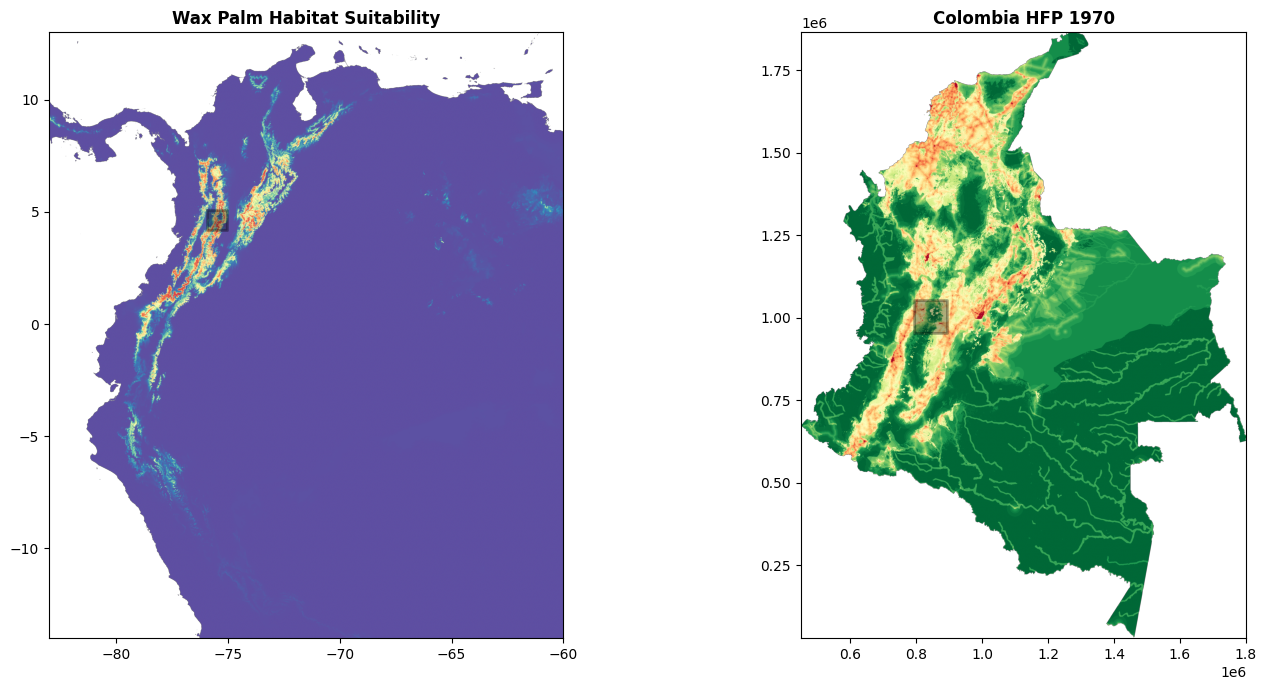

Habitat matrix shape: (109, 109)
Footprint matrix shape: (109, 109)
Pixel resolution: 0.008333333333333333 x 0.008333333333333333


In [2]:
# Define paths
habitat_path = r"C:\Users\Carlos Munoz\Documents\Ph.D\6_courses\2026_I_jsdmcapt\data\exp_1\Ceroxylon_quindiuense_mx.tif"
footprint_path = r"C:\Users\Carlos Munoz\Documents\Ph.D\6_courses\2026_I_jsdmcapt\data\colombia_hfi\IHEH_1970.tif"
shapefile_path = r"C:\Users\Carlos Munoz\Documents\Ph.D\6_courses\2026_I_jsdmcapt\data\exp_1\cocora_100km.shp"

def process_and_crop(src: rasterio.io.DatasetReader, extent_gdf: gpd.GeoDataFrame) -> tuple[np.ndarray, dict]:
    # Reproject shapefile to match the raster CRS if they differ
    if extent_gdf.crs != src.crs:
        extent_gdf = extent_gdf.to_crs(src.crs)

    # Extract geometry in GeoJSON format for the mask function
    geometries = [mapping(geom) for geom in extent_gdf.geometry]

    # Crop raster
    out_image, out_transform = mask(src, geometries, crop=True)

    # Update metadata to reflect the new dimensions
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    return out_image[0], out_meta

# Call shapefile
extent = gpd.read_file(shapefile_path)

# Open rasters, plot them, and crop
with rasterio.open(habitat_path) as h_src, rasterio.open(footprint_path) as f_src:

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Reproject extent for plotting if needed
    extent_h = extent.to_crs(h_src.crs) if extent.crs != h_src.crs else extent
    extent_f = extent.to_crs(f_src.crs) if extent.crs != f_src.crs else extent

    cmap_habitat = plt.get_cmap('Spectral_r')
    cmap_footprint = plt.get_cmap('RdYlGn_r')

    # Plot Habitat
    show(h_src, ax=axes[0], cmap=cmap_habitat, title='Wax Palm Habitat Suitability')
    extent_h.plot(ax=axes[0], facecolor='black', alpha=0.3, edgecolor='black', linewidth=2)

    # Plot Footprint
    show(f_src, ax=axes[1], cmap=cmap_footprint, title='Colombia HFP 1970')
    extent_f.plot(ax=axes[1], facecolor='black', alpha=0.3, edgecolor='black', linewidth=2)

    plt.tight_layout()
    plt.show()

    # Cropping
    h_layer, h_meta = process_and_crop(h_src, extent)
    h_layer[h_layer < 0] = 0  # Set negative values to zero/ NA labels

    # Use WarpedVRT to reproject f_src to match h_src's CRS and resolution before cropping
    with WarpedVRT(f_src, crs=h_src.crs, transform=h_src.transform, width=h_src.width, height=h_src.height) as vrt:
        footprint_layer, footprint_meta = process_and_crop(vrt, extent)


# Verify matrix alignment
print(f"Habitat matrix shape: {h_layer.shape}")
print(f"Footprint matrix shape: {footprint_layer.shape}")

# Verify spatial resolution
pixel_width = h_meta['transform'][0]
pixel_height = -h_meta['transform'][4]
print(f"Pixel resolution: {pixel_width} x {pixel_height}")


In [3]:
@dataclass
class SpeciesParameters:
    name: str
    K_s: float
    G_s: float
    S_s: float
    D_s: float
    d_max: float

class EnvironmentalModel:
    def __init__(self, h_layer: np.ndarray, footprint_layer: np.ndarray, params: SpeciesParameters):
        self.params = params
        self.H_c = h_layer
        self.delta_c = footprint_layer / 100.0
        self.K_c = self.H_c * self.params.K_s

        # Initialization: current state of range contraction 54% of the original range, which is equivalent to 46% of the original population size.
        self.N_c = np.floor(self.K_c * 0.46).astype(int)

    def _calculate_immigration(self) -> np.ndarray:
        # Set to zero for the isolated demographic test.
        return np.zeros_like(self.N_c)

    def step_original_captain(self):
        """
        Original CAPTAIN formulation with geometric growth and hard capacity limit.
        Equation 4: N = min(N * (1 - S*delta) * G + I, K)
        """
        surviving_pop = self.N_c * (1.0 - (self.params.S_s * self.delta_c))
        growing_pop = surviving_pop * self.params.G_s
        immigrants = self._calculate_immigration()

        self.N_c = np.minimum(growing_pop + immigrants, self.K_c)

    def step_logistic_captain(self):
        """
        CAPTAIN formulation with logistic growth.
        Equation 26: N = (K * Surviving * G) / (K + Surviving * (G - 1)) + I
        """
        surviving_pop = self.N_c * (1.0 - (self.params.S_s * self.delta_c))

        numerator = self.K_c * surviving_pop * self.params.G_s
        denominator = self.K_c + (surviving_pop * (self.params.G_s - 1.0))

        # Safe division to prevent errors where K_c and surviving_pop are 0
        growing_pop = np.divide(
            numerator,
            denominator,
            out=np.zeros_like(numerator),
            where=denominator > 0
        )

        immigrants = self._calculate_immigration()

        self.N_c = growing_pop + immigrants

In [4]:
# 1. Calculate K_s
# K_s based on the San Juanito pristine density (31 individuals per hectare)
calculated_K_s = 31.0 * 100 # although the area should vary a little because of the pixel size, we use 100 to maintain consistency in this first approach.

# 2. Define the biological parameters
# Dispersal components are set to 0 to isolate the local demographic equations.
palm_params = SpeciesParameters(
    name="Ceroxylum quindiuense",
    K_s= calculated_K_s,
    G_s=1.05,  # 5% intrinsic growth rate
    S_s=0.25,  # 25% mortality under maximum disturbance
    D_s=0.0,
    d_max=0
)

# 3. Initiate two independent models
model_original = EnvironmentalModel(h_layer, footprint_layer, palm_params)
model_logistic = EnvironmentalModel(h_layer, footprint_layer, palm_params)

# 4. Run simulations
time_steps = 100

# Initialize lists to store the full N_c matrices at each time step
full_traj_original = []
full_traj_logistic = []

for t in range(time_steps):
    # Record the current state of N_c for the entire matrix
    full_traj_original.append(model_original.N_c.copy())
    full_traj_logistic.append(model_logistic.N_c.copy())

    # Advance both models, which updates their N_c matrices for the entire grid
    model_original.step_original_captain()
    model_logistic.step_logistic_captain()

## Visualization

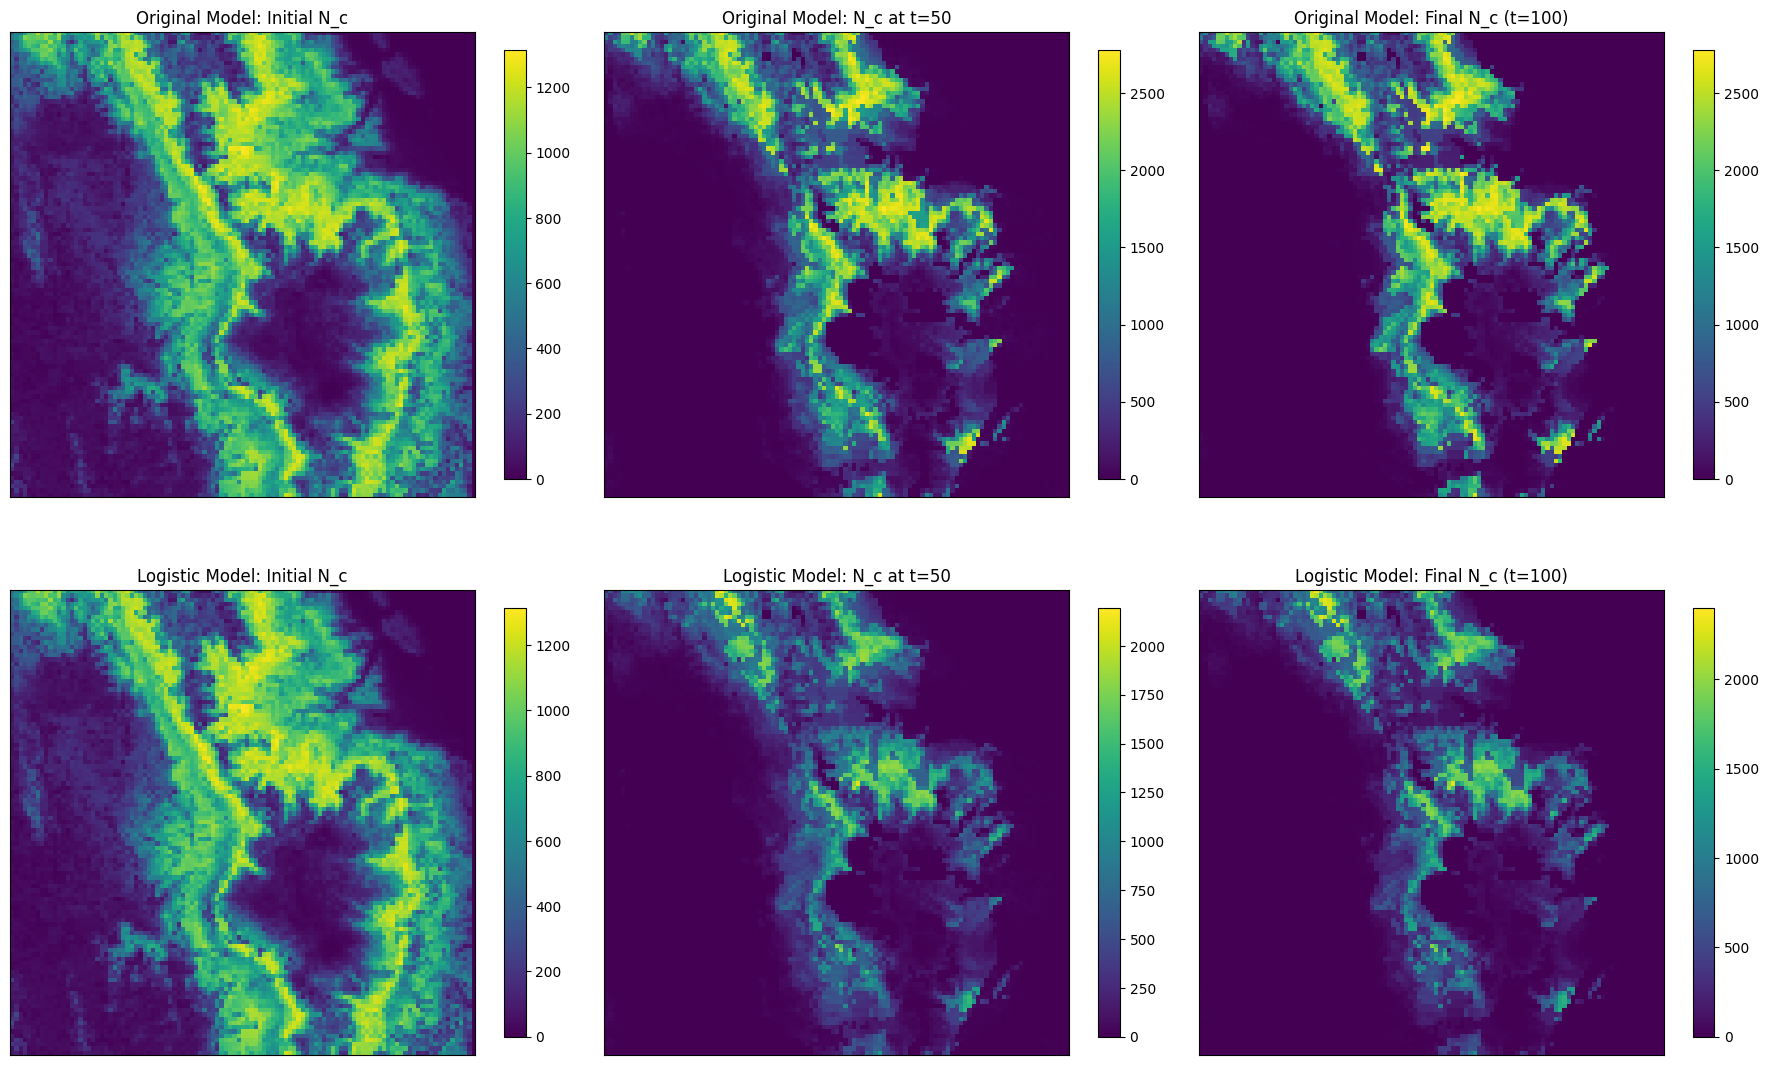

In [6]:
# Get the N_c matrices at initial, a mid, and final time step

mid_time_step = time_steps // 2
final_time_step = time_steps -1

n_c_original_initial = full_traj_original[0]
n_c_original_mid = full_traj_original[mid_time_step] if len(full_traj_original) > mid_time_step else full_traj_original[-1]
n_c_original_final = full_traj_original[final_time_step]

n_c_logistic_initial = full_traj_logistic[0]
n_c_logistic_mid = full_traj_logistic[mid_time_step] if len(full_traj_logistic) > mid_time_step else full_traj_logistic[-1]
n_c_logistic_final = full_traj_logistic[final_time_step]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original Model Row
im1 = axes[0, 0].imshow(n_c_original_initial, cmap='viridis', origin='lower')
axes[0, 0].set_title('Original Model: Initial N_c')
fig.colorbar(im1, ax=axes[0, 0], shrink=0.7)

im2 = axes[0, 1].imshow(n_c_original_mid, cmap='viridis', origin='lower')
axes[0, 1].set_title(f'Original Model: N_c at t={mid_time_step}')
fig.colorbar(im2, ax=axes[0, 1], shrink=0.7)

im3 = axes[0, 2].imshow(n_c_original_final, cmap='viridis', origin='lower')
axes[0, 2].set_title(f'Original Model: Final N_c (t={final_time_step+1})')
fig.colorbar(im3, ax=axes[0, 2], shrink=0.7)

# Logistic Model Row
im4 = axes[1, 0].imshow(n_c_logistic_initial, cmap='viridis', origin='lower')
axes[1, 0].set_title('Logistic Model: Initial N_c')
fig.colorbar(im4, ax=axes[1, 0], shrink=0.7)

im5 = axes[1, 1].imshow(n_c_logistic_mid, cmap='viridis', origin='lower')
axes[1, 1].set_title(f'Logistic Model: N_c at t={mid_time_step}')
fig.colorbar(im5, ax=axes[1, 1], shrink=0.7)

im6 = axes[1, 2].imshow(n_c_logistic_final, cmap='viridis', origin='lower')
axes[1, 2].set_title(f'Logistic Model: Final N_c (t={final_time_step+1})')
fig.colorbar(im6, ax=axes[1, 2], shrink=0.7)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

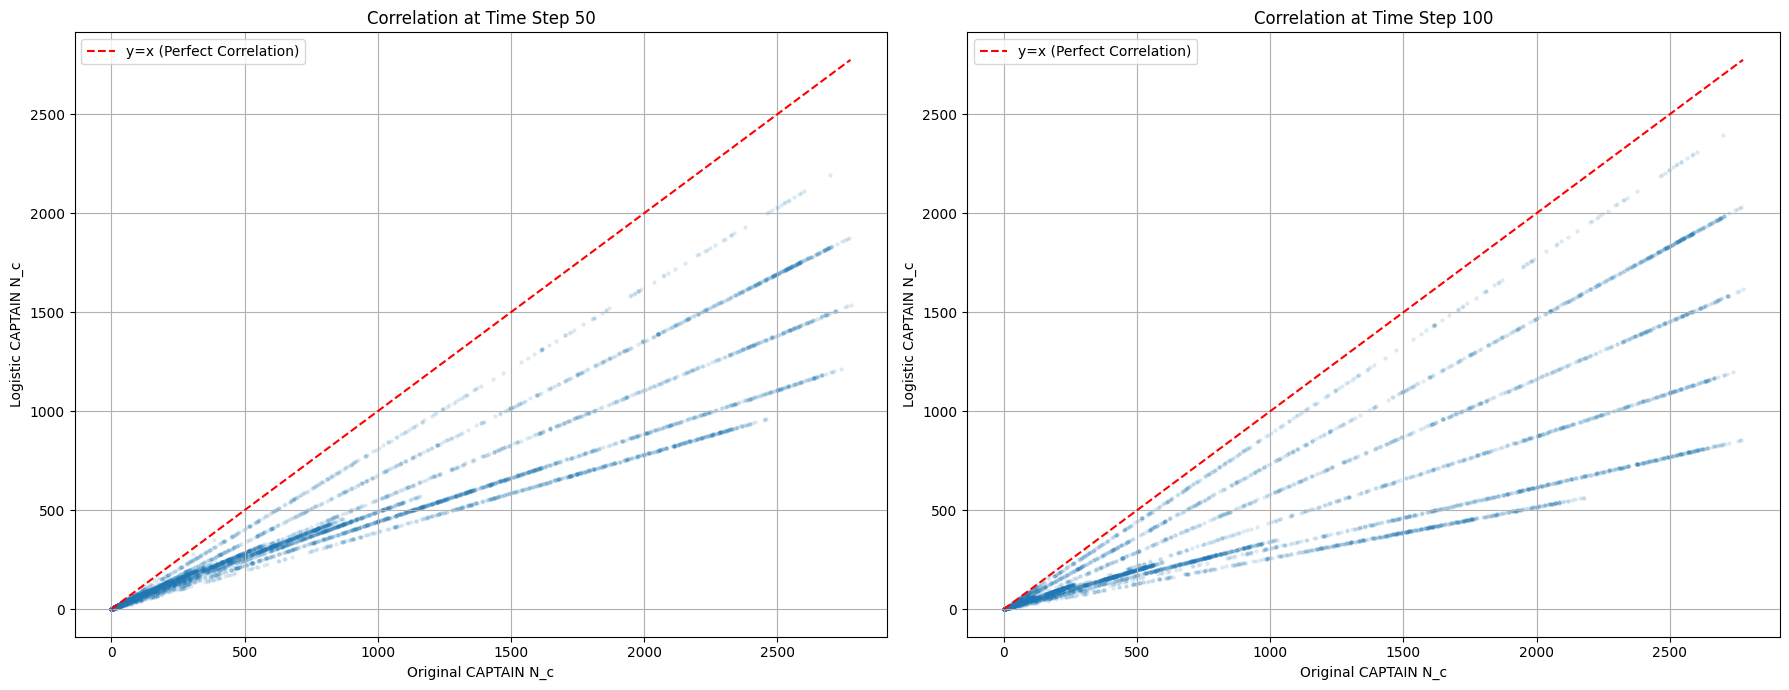

In [8]:
n_c_original_mid = n_c_original_mid.flatten()
n_c_logistic_mid = n_c_logistic_mid.flatten()

n_c_original_final = n_c_original_final.flatten()
n_c_logistic_final = n_c_logistic_final.flatten()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for mid time step
axes[0].scatter(n_c_original_mid, n_c_logistic_mid, alpha=0.1, s=5)
axes[0].set_title(f'Correlation at Time Step {mid_time_step}')
axes[0].set_xlabel('Original CAPTAIN N_c')
axes[0].set_ylabel('Logistic CAPTAIN N_c')
# Add a y=x line for comparison
min_val = min(n_c_original_mid.min(), n_c_logistic_mid.min())
max_val = max(n_c_original_mid.max(), n_c_logistic_mid.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x (Perfect Correlation)')
axes[0].legend()
axes[0].grid(True)

# Plot for final time step
axes[1].scatter(n_c_original_final, n_c_logistic_final, alpha=0.1, s=5)
axes[1].set_title(f'Correlation at Time Step {final_time_step+1}')
axes[1].set_xlabel('Original CAPTAIN N_c')
axes[1].set_ylabel('Logistic CAPTAIN N_c')
# Add a y=x line for comparison
min_val = min(n_c_original_final.min(), n_c_logistic_final.min())
max_val = max(n_c_original_final.max(), n_c_logistic_final.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x (Perfect Correlation)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Plot the comparative trajectories for all cells

C:\Users\Carlos Munoz\AppData\Local\Temp\ipykernel_29280\1285599701.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Carlos Munoz\Documents\Ph.D\6_courses\2026_I_jsdmcapt\jsdmcapt\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


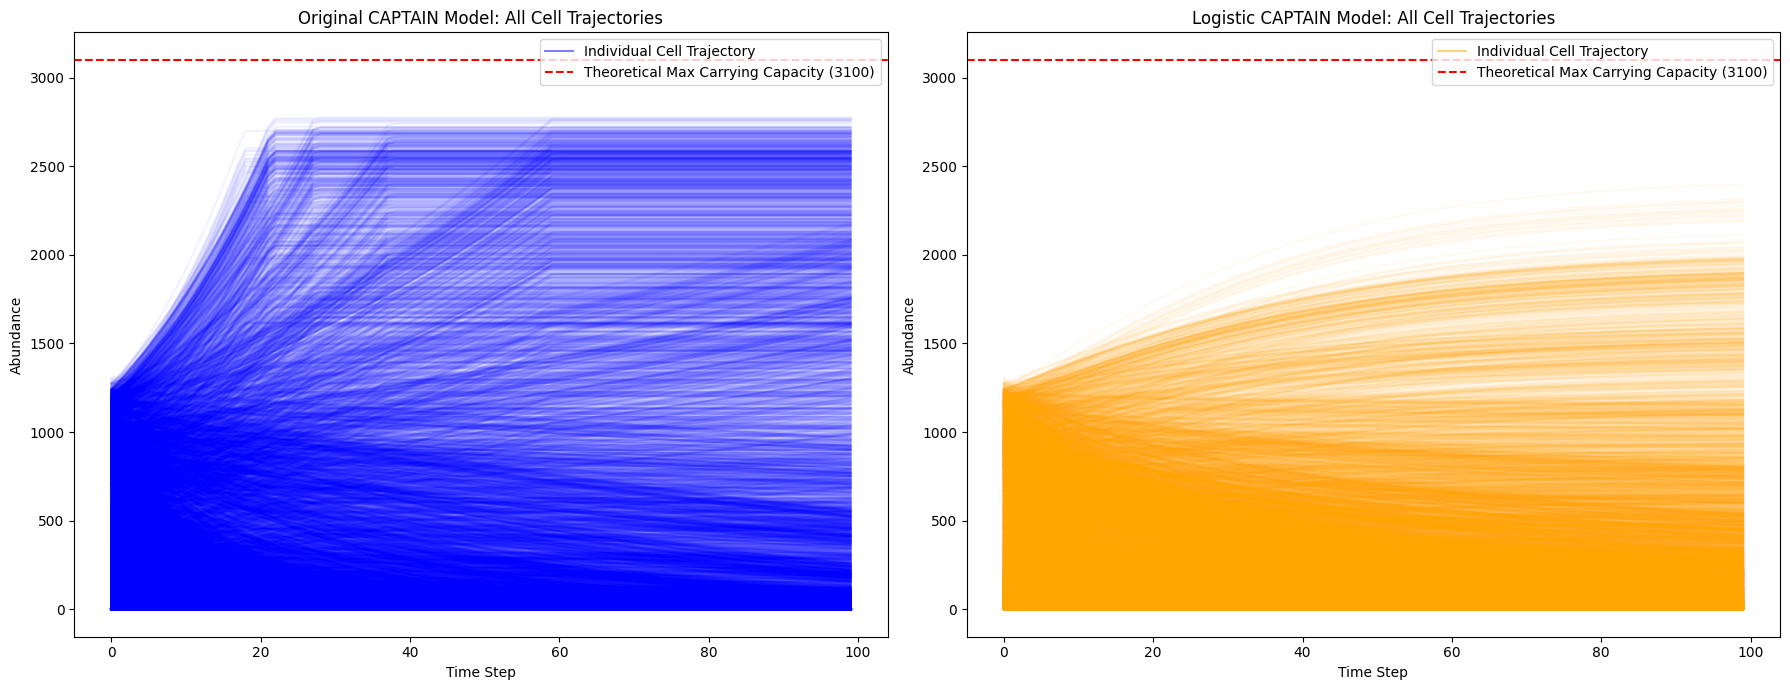

In [9]:
# Convert list of 2D arrays (time, height, width) into a 3D array for easier processing
traj_original_3d = np.array(full_traj_original)
traj_logistic_3d = np.array(full_traj_logistic)

# Reshape to (time_steps, num_cells) for plotting all trajectories
# num_cells = h_layer.shape[0] * h_layer.shape[1]
num_cells = traj_original_3d.shape[1] * traj_original_3d.shape[2]

traj_original_2d = traj_original_3d.reshape(time_steps, num_cells)
traj_logistic_2d = traj_logistic_3d.reshape(time_steps, num_cells)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Original CAPTAIN
for i in range(num_cells):
    ax1.plot(traj_original_2d[:, i], color='blue', alpha=0.05) # Use low alpha for many lines
ax1.set_title("Original CAPTAIN Model: All Cell Trajectories")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Abundance")
# legend to represent all lines
ax1.plot([], [], color='blue', alpha=0.5, label='Individual Cell Trajectory')
ax1.axhline(y=3100, color='red', linestyle='--', label='Theoretical Max Carrying Capacity (3100)')
ax1.legend()

# Logistic CAPTAIN
for i in range(num_cells):
    ax2.plot(traj_logistic_2d[:, i], color='orange', alpha=0.05) # Use low alpha for many lines
ax2.set_title("Logistic CAPTAIN Model: All Cell Trajectories")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Abundance")
ax2.plot([], [], color='orange', alpha=0.5, label='Individual Cell Trajectory')
ax2.axhline(y=3100, color='red', linestyle='--', label='Theoretical Max Carrying Capacity (3100)')
ax2.legend()

plt.tight_layout()
plt.show()